Fourier Series Reconstruction of Letter Outlines

Part 2 : Data Loading

In [1]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

# function for loading letter data
def load_letter_data(filename):
    pts = np.loadtxt(filename, delimiter=',', skiprows=1)
        
# convert X, Y columns to complex numbers (x + iy)
    z = pts[:, 0] + 1j * pts[:, 1]        
# create time parameter t from 0 to 1
    N = len(z)
    t = np.linspace(0, 1, N, endpoint=False) # dividing the interval 
    return z, t

Part 3 : Fourier Coefficent Calculation 

In [2]:
# function of calculating fourier coefficients
def fourier_coefficients(z, t, M):
    coeffs = {}
    # N is the number of sample points
    N = len(z)
    # Step size dt = 1/N (since total period T=1)
    dt = 1.0 / N
    for k in range(-M, M + 1): # looping through all modes
        integrand = z * np.exp(-1j * 2 * np.pi * k * t) # integrand is an array containing elements of different z and t (1 st element of t and z is taken then value is computed and then stored as first element of integrand array.)
        c_k = np.sum(integrand) * dt # applying composite trapezoid rule summing the elements of for all t/z  (basically covering the interval)
        coeffs[k] = c_k # stored in dictionary
    return coeffs

Part 4 : Reconstructing the curve

In [3]:
# function for reconstruction of the curve 
def reconstruct_curve(coeffs, M, num_points=1000):
    t_smooth = np.linspace(0, 1, num_points, endpoint=False)
    z_reconstructed = np.zeros_like(t_smooth, dtype=complex)
    for k in range(-M, M + 1): # summing up all modes
        z_reconstructed += coeffs[k] * np.exp(1j * 2 * np.pi * k * t_smooth)
    return z_reconstructed    

Part 5 : Visualization

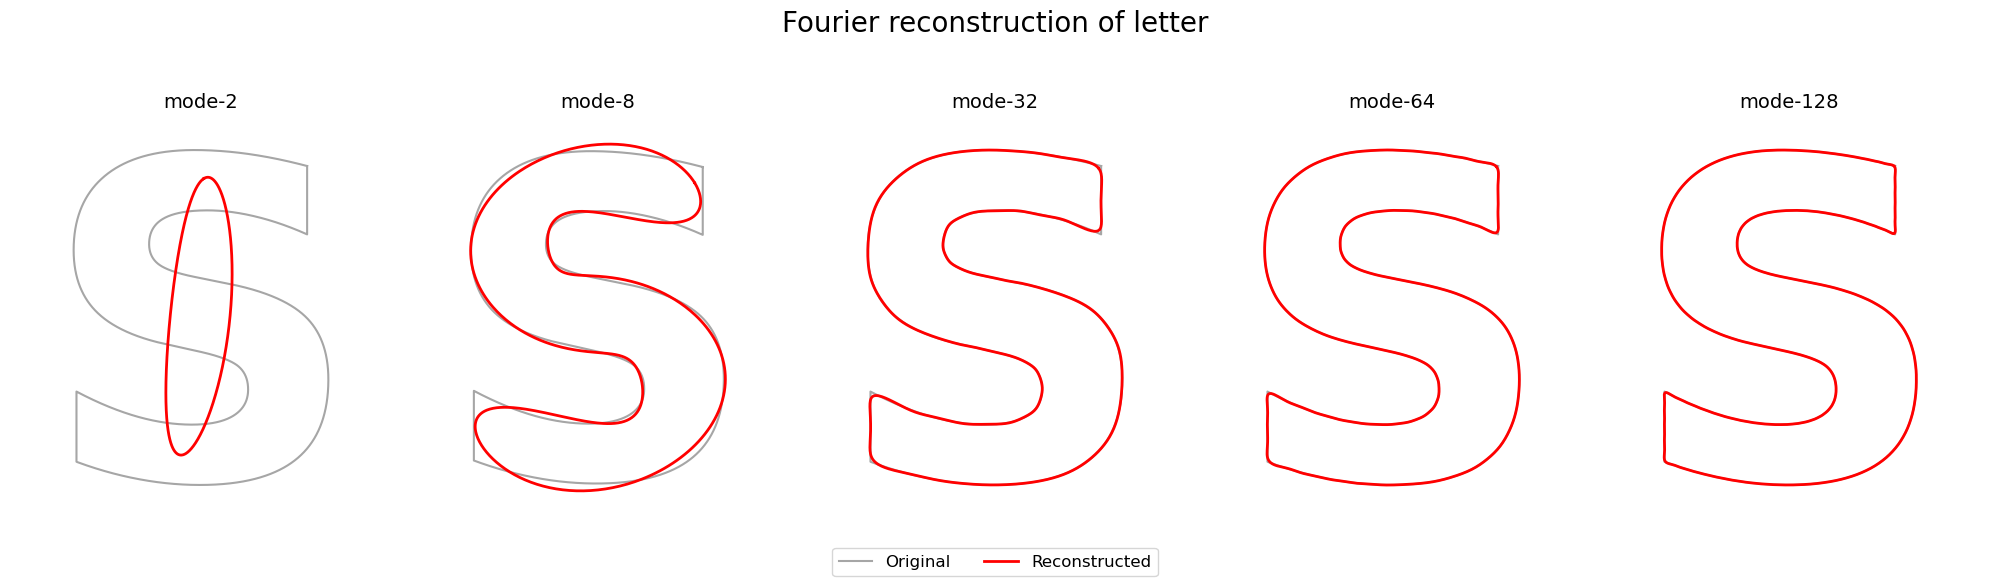

In [4]:
filename = 'S.csv'  
z, t = load_letter_data(filename)

# calculateing coefficients for the maximum M required (M=128)
# this dictionary contains all the coefficeints we need for smaller M's too.
max_M = 128
all_coeffs = fourier_coefficients(z, t, max_M)

M_values = [2, 8, 32, 64, 128]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Fourier reconstruction of letter", fontsize=20, y=1.05)

for i, M in enumerate(M_values):
    ax = axes[i]
    z_rec = reconstruct_curve(all_coeffs, M)

    z_plot = np.append(z, z[0]) 
    ax.plot(z_plot.real, z_plot.imag, color='gray', linewidth=1.5, alpha=0.7, label='Original')

    ax.plot(z_rec.real, z_rec.imag, color='red', linewidth=2, label='Reconstructed')
    ax.set_title(f"mode-{M}", fontsize=14)
    ax.axis('equal')
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1), fontsize=12)

plt.tight_layout()
plt.savefig("S.png", dpi = 600)
plt.show()    

Part 6 : Animation

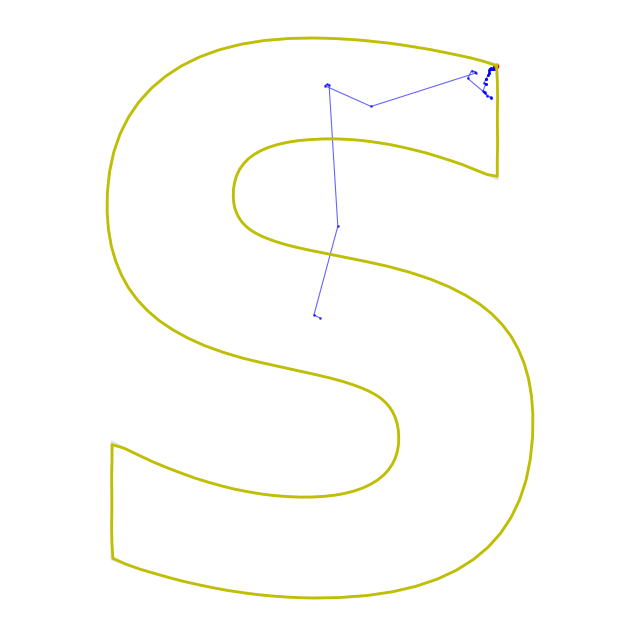

In [5]:
import matplotlib.animation as animation
# setting up data
filename = 'S.csv' 
z, t = load_letter_data(filename)

# animation for M = 128
max_M = 128  
coeffs = fourier_coefficients(z, t, max_M)

# sorting modes for robotic arm structure
# Order: 0, 1, -1, 2, -2, ... up to 128, -128
sorted_modes = [0]
for k in range(1, max_M + 1):
    sorted_modes.extend([k, -k])

# setting up the figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(np.min(z.real)-30, np.max(z.real)+30)
ax.set_ylim(np.min(z.imag)-30, np.max(z.imag)+30)
ax.axis('equal')
ax.axis('off')

# Plot Elements
# real element S (behind)
z_plot = np.append(z, z[0])
ax.plot(z_plot.real, z_plot.imag, 'gray', alpha=0.2, linewidth=2)

# robotic arm
vectors_line, = ax.plot([], [], 'b-o', lw=0.8, markersize=1, alpha=0.6)

# End point
pen_dot, = ax.plot([], [], 'ro', markersize=3)

# trace line
trace_line, = ax.plot([], [], 'y-', lw=2)
trace_x, trace_y = [], []

#  Update Function
def update(frame_idx):
    # 200 frames total for smooth motion
    current_t = frame_idx / 200.0 
    
    points = [0] 
    current_pos = 0
    
    # Sum up all 257 vectors (0 plus +/- 1 to 128)
    for k in sorted_modes:
        val = coeffs[k] * np.exp(1j * 2 * np.pi * k * current_t)
        current_pos += val
        points.append(current_pos)
    
    points = np.array(points)
    
    # updating lines
    vectors_line.set_data(points.real, points.imag)
    
    tip = points[-1]
    pen_dot.set_data([tip.real], [tip.imag])
    
    trace_x.append(tip.real)
    trace_y.append(tip.imag)
    trace_line.set_data(trace_x, trace_y)
    
    return vectors_line, pen_dot, trace_line


ani = animation.FuncAnimation(fig, update, frames=201, interval=30, blit=True)

output_file = "fourier_robotic_arm_128.gif"
ani.save(output_file, writer='pillow', fps=30)

plt.show()